# Lekcja 25 — Uczenie sieci: straty i optymalizacja

Notebook ze **poleceniami** (zadania domowe z PDF).  
Każde zadanie = komórka markdown + **pusta** komórka kodu — rozwiązujesz samodzielnie.

**Zakres domowe:** zadania 1–12 (łatwe + średnie).  
**Challenge 13–20:** opcjonalnie, opis na końcu.


# Zadanie 1 — Funkcje strat ręcznie

Zaimplementuj **MSE**, **MAE** i **Huber Loss** od zera i porównaj na przykładowych danych.

**Wymagania:**
- `y_true = [3.0, 5.0, 2.5, 7.0]`, `y_pred = [2.8, 5.5, 2.0, 10.0]`
- Oblicz MSE, MAE, Huber (`delta=1.0`)
- Narysuj wykres 3 funkcji strat jako funkcji błędu (od −4 do 4)
- Opisz, która jest najbardziej czuła na outliery

**Oczekiwany wynik:** wartości numeryczne + wykres porównawczy


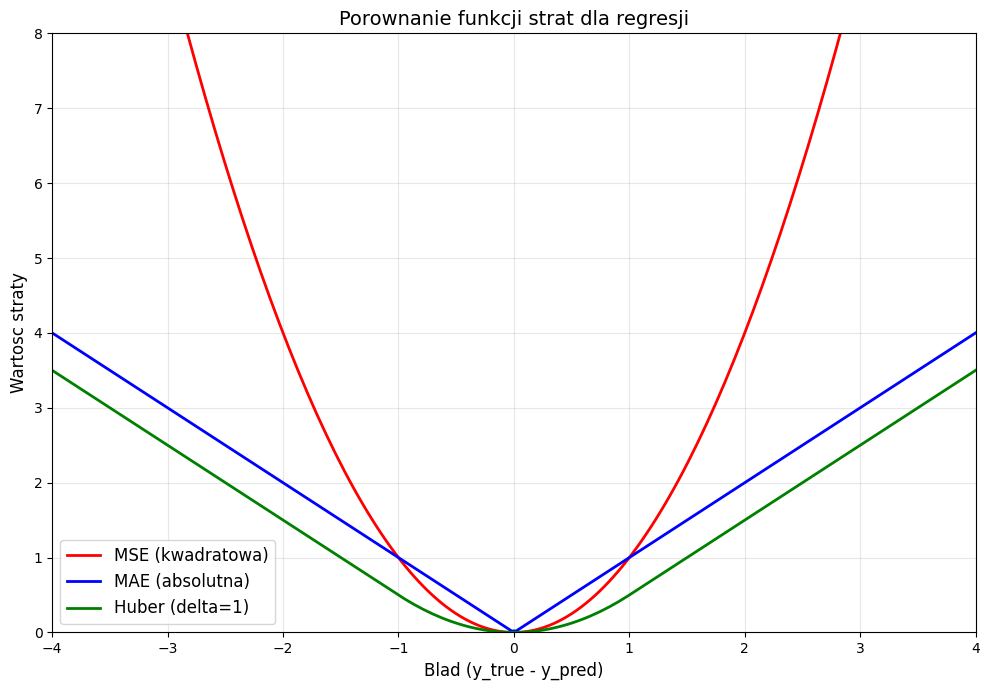

Dane: y_true = [3.  5.  2.5 7. ] y_pred = [ 2.8  5.5  2.  10. ]
MSE: 2.3850 (czula na outlier: 10.0 vs7.0)
MAE: 1.0500 (odporniejsza na outlier)
Huber: 0.6925 (kompromis)


In [1]:
# Funkcje strat dla regresji -- implementacja od zera
import numpy as np
import matplotlib.pyplot as plt

def mse_loss(y_true, y_pred):
    """Mean Squared Error: L = (1/n) * sum((y - y_pred)^2)
    Karze duze bledy mocniej (kwadrat). Czula na outliers."""
    return np.mean((y_true - y_pred) ** 2)

def mse_gradient(y_true, y_pred):
    """Gradient MSE wzgledem predykcji: dL/dy_pred = -2/n * (y - y_pred)"""
    n = len(y_true)
    return -2 / n * (y_true - y_pred)

def mae_loss(y_true, y_pred):
    """Mean Absolute Error: L = (1/n) * sum(|y - y_pred|)
    Odporniejsza na outliers niz MSE."""
    return np.mean(np.abs(y_true - y_pred))

def huber_loss(y_true, y_pred, delta=1.0):
    """Huber Loss: MSE dla malych bledow, MAE dla duzych.
    Kompromis miedzy MSE i MAE. Parametr delta kontroluje prog."""
    error = y_true - y_pred
    is_small = np.abs(error) <= delta
    squared = 0.5 * error ** 2
    linear = delta * np.abs(error) - 0.5 * delta ** 2
    return np.mean(np.where(is_small, squared, linear))

# Wizualizacja: jak rozne loss reaguja na bledy
errors = np.linspace(-4, 4, 200)
y_true_demo = np.zeros_like(errors)
y_pred_demo = errors

mse_values = [(e ** 2) for e in errors]
mae_values = [abs(e) for e in errors]
huber_values = [0.5 * e**2 if abs(e) <= 1 else abs(e) - 0.5 for e in errors]

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(errors, mse_values, 'r-', linewidth=2, label='MSE (kwadratowa)')
ax.plot(errors, mae_values, 'b-', linewidth=2, label='MAE (absolutna)')
ax.plot(errors, huber_values, 'g-', linewidth=2, label='Huber (delta=1)')
ax.set_xlabel('Blad (y_true - y_pred)', fontsize=12)
ax.set_ylabel('Wartosc straty', fontsize=12)
ax.set_title('Porownanie funkcji strat dla regresji', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(-4, 4)
ax.set_ylim(0, 8)
plt.tight_layout()
plt.show()

# Przyklad numeryczny
y_true = np.array([3.0, 5.0, 2.5, 7.0])
y_pred = np.array([2.8, 5.5, 2.0, 10.0]) # ostatnia predykcja -- duzy blad(outlier)

print("Dane: y_true =", y_true, "y_pred =", y_pred)
print(f"MSE: {mse_loss(y_true, y_pred):.4f} (czula na outlier: 10.0 vs7.0)")
print(f"MAE: {mae_loss(y_true, y_pred):.4f} (odporniejsza na outlier)")
print(f"Huber: {huber_loss(y_true, y_pred):.4f} (kompromis)")


# Zadanie 2 — Binary Cross-Entropy

Zaimplementuj **BCE** i pokaż, jak karze pewne błędy.

**Wymagania:**
- 4 scenariusze: pewna poprawna (y=1, p=0.99), pewna błędna (y=1, p=0.01), niepewna poprawna (y=1, p=0.6), niepewna błędna (y=1, p=0.4)
- Wykres: BCE jako funkcja p dla y=1 i y=0
- Wyjaśnij, dlaczego pewna zła predykcja jest tak mocno karana

**Oczekiwany wynik:** tabela BCE + 2 wykresy


=== OCZEKIWANY WYNIK: TABELA SCENARIUSZY BCE ===
       Scenariusz  y_true  y_pred (p)  BCE Loss
   Pewna poprawna       1      0.9900    0.0101
Niepewna poprawna       1      0.6000    0.5108
  Niepewna błędna       1      0.4000    0.9163
     Pewna błędna       1      0.0100    4.6052




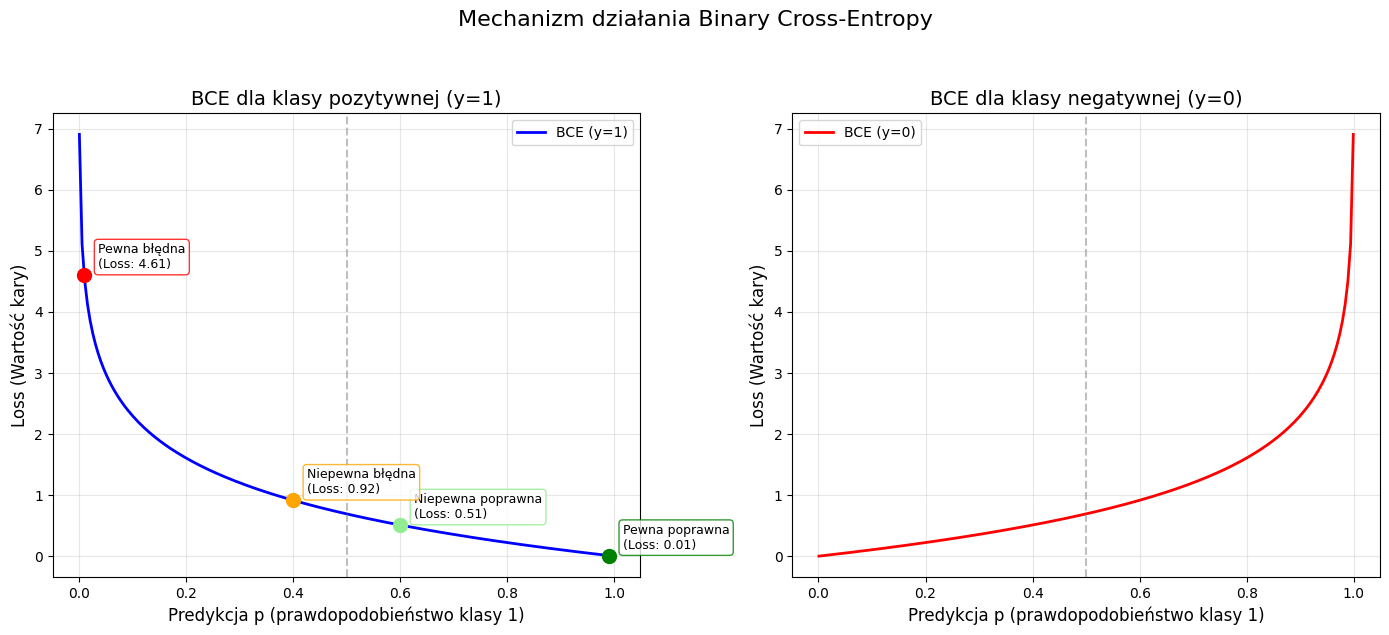

In [2]:
# Binary Cross-Entropy -- klasyfikacja binarna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def binary_cross_entropy_single(y_true, y_pred, eps=1e-15):
    """
    Oblicza BCE dla pojedynczego przypadku.
    eps chroni przed próbą wyliczenia logarytmu z zera.
    """
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# --- WYMAGANIE 1: 4 Scenariusze (dla y=1) ---
scenarios = [
    {"Opis": "Pewna poprawna", "y": 1, "p": 0.99},
    {"Opis": "Niepewna poprawna", "y": 1, "p": 0.60},
    {"Opis": "Niepewna błędna", "y": 1, "p": 0.40},
    {"Opis": "Pewna błędna", "y": 1, "p": 0.01},
]

# Obliczanie wyników do tabeli
results = []
for s in scenarios:
    loss = binary_cross_entropy_single(s["y"], s["p"])
    results.append({
        "Scenariusz": s["Opis"], 
        "y_true": s["y"], 
        "y_pred (p)": s["p"], 
        "BCE Loss": loss
    })

df_results = pd.DataFrame(results)

print("=== OCZEKIWANY WYNIK: TABELA SCENARIUSZY BCE ===")
print(df_results.to_string(index=False, float_format="%.4f"))
print("\n")

# --- WYMAGANIE 2: Wykresy ---
p_range = np.linspace(0.001, 0.999, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Wykres 1: Gdy y_true = 1
loss_for_1 = -np.log(p_range)
ax1.plot(p_range, loss_for_1, 'b-', linewidth=2, label='BCE (y=1)')

# Zaznaczenie 4 scenariuszy na pierwszym wykresie
colors = ['green', 'lightgreen', 'orange', 'red']
for (idx, row), color in zip(df_results.iterrows(), colors):
    ax1.plot(row['y_pred (p)'], row['BCE Loss'], marker='o', markersize=10, color=color)
    ax1.annotate(
        f"{row['Scenariusz']}\n(Loss: {row['BCE Loss']:.2f})", 
        (row['y_pred (p)'], row['BCE Loss']), 
        xytext=(10, 5), textcoords='offset points', fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, lw=1, alpha=0.8)
    )

ax1.set_xlabel('Predykcja p (prawdopodobieństwo klasy 1)', fontsize=12)
ax1.set_ylabel('Loss (Wartość kary)', fontsize=12)
ax1.set_title('BCE dla klasy pozytywnej (y=1)', fontsize=14)
ax1.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Wykres 2: Gdy y_true = 0
loss_for_0 = -np.log(1 - p_range)
ax2.plot(p_range, loss_for_0, 'r-', linewidth=2, label='BCE (y=0)')
ax2.set_xlabel('Predykcja p (prawdopodobieństwo klasy 1)', fontsize=12)
ax2.set_ylabel('Loss (Wartość kary)', fontsize=12)
ax2.set_title('BCE dla klasy negatywnej (y=0)', fontsize=14)
ax2.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.suptitle('Mechanizm działania Binary Cross-Entropy', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

# Zadanie 3 — Softmax i Categorical Cross-Entropy

Zaimplementuj **softmax** (stabilność numeryczna: odejmij max) i **CCE**.

**Wymagania:**
- One-hot encoding
- 3 klasy, 4 próbki — dobre i złe predykcje
- Sprawdź, że softmax daje sumę = 1

**Oczekiwany wynik:** wartości CCE + weryfikacja softmax


In [3]:
import numpy as np

# 1. Implementacja Softmax (ze stabilnością numeryczną)
def softmax(z):
    """
    Przekształca surowe wyniki modelu w prawdopodobieństwa (sumujące się do 1).
    Stabilność numeryczna: od każdego wiersza odejmujemy jego wartość maksymalną.
    """
    # Znajdujemy największą wartość w każdym wierszu (zmienna pomocnicza)
    z_max = np.max(z, axis=1, keepdims=True)
    
    # Odejmowanie z_max zapobiega błędom przepełnienia (overflow) przy potęgowaniu
    exp_z = np.exp(z - z_max)
    
    # Dzielimy przez sumę, aby uzyskać proporcje (prawdopodobieństwa)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# 2. Funkcje CCE i One-Hot (z Twojego przykładu)
def categorical_cross_entropy(y_true_onehot, y_pred_proba, eps=1e-15):
    """CCE: L = -(1/n) * sum(sum(y_k * log(p_k)))"""
    y_pred_proba = np.clip(y_pred_proba, eps, 1 - eps)
    return -np.mean(np.sum(y_true_onehot * np.log(y_pred_proba), axis=1))

def to_onehot(y, n_classes):
    """Zamiana etykiet na macierz one-hot."""
    onehot = np.zeros((len(y), n_classes))
    onehot[np.arange(len(y)), y] = 1
    return onehot

# --- WERYFIKACJA 1: TEST FUNKCJI SOFTMAX ---
print("=== 1. WERYFIKACJA SOFTMAX (SUMA = 1) ===")
# Symulujemy surowe wyniki (tzw. logity), które sieć neuronowa wypluwa przed Softmaxem
surowe_wyniki = np.array([
    [5.0, 2.0, -1.0],  # Model silnie stawia na klasę 0
    [-3.0, 8.0, 1.0]   # Model silnie stawia na klasę 1
])

prawdopodobienstwa = softmax(surowe_wyniki)
print("Surowe wyniki (logity):")
print(surowe_wyniki)
print("\nPo przejściu przez Softmax:")
print(prawdopodobienstwa)

suma_wierszy = np.sum(prawdopodobienstwa, axis=1)
print(f"\nSuma wiersza 1: {suma_wierszy[0]:.4f}")
print(f"Suma wiersza 2: {suma_wierszy[1]:.4f}")
print("Czy Softmax daje sumę = 1?", np.allclose(suma_wierszy, 1.0))
print("\n" + "="*40 + "\n")

# --- WERYFIKACJA 2: OBLICZANIE KARY CCE ---
print("=== 2. WYNIKI CATEGORICAL CROSS-ENTROPY ===")
y_example = np.array([0, 1, 2, 0])
y_onehot = to_onehot(y_example, 3)

# Dobre predykcje 
y_pred_good_multi = np.array([
    [0.9, 0.05, 0.05], # klasa 0 -- pewna
    [0.1, 0.8, 0.1],   # klasa 1 -- pewna
    [0.05, 0.05, 0.9], # klasa 2 -- pewna
    [0.7, 0.2, 0.1],   # klasa 0 -- dosc pewna
])

# Złe predykcje
y_pred_bad_multi = np.array([
    [0.3, 0.4, 0.3], # klasa 0 -- niepewna (najwiecej ma 1!)
    [0.4, 0.3, 0.3], # klasa 1 -- pomylka (najwiecej ma 0!)
    [0.3, 0.3, 0.4], # klasa 2 -- ledwo (ale trafiona)
    [0.2, 0.5, 0.3], # klasa 0 -- pomylka (najwiecej ma 1!)
])

print("Macierz One-Hot dla poprawnych odpowiedzi (y_true):")
print(y_onehot)
print(f"\nCCE (dobre predykcje): {categorical_cross_entropy(y_onehot, y_pred_good_multi):.4f}")
print(f"CCE (złe predykcje): {categorical_cross_entropy(y_onehot, y_pred_bad_multi):.4f}")

=== 1. WERYFIKACJA SOFTMAX (SUMA = 1) ===
Surowe wyniki (logity):
[[ 5.  2. -1.]
 [-3.  8.  1.]]

Po przejściu przez Softmax:
[[9.50330212e-01 4.73141552e-02 2.35563308e-03]
 [1.66862063e-05 9.99072278e-01 9.11035992e-04]]

Suma wiersza 1: 1.0000
Suma wiersza 2: 1.0000
Czy Softmax daje sumę = 1? True


=== 2. WYNIKI CATEGORICAL CROSS-ENTROPY ===
Macierz One-Hot dla poprawnych odpowiedzi (y_true):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]

CCE (dobre predykcje): 0.1976
CCE (złe predykcje): 1.2334


# Zadanie 4 — Forward pass ręcznie

Oblicz ręcznie (krok po kroku), potem zweryfikuj kodem.

**Sieć:** 2 wejścia → 2 ukryte (ReLU) → 1 wyjście (sigmoid)

**Wagi:**
- `W1 = [[0.5, -0.3], [0.2, 0.8]]`, `b1 = [0, 0]`
- `W2 = [[0.7], [-0.4]]`, `b2 = [0.1]`
- Wejście: `x = [1.0, 0.5]`

**Oblicz:** z1, a1, z2, a2

**Oczekiwany wynik:** obliczenia krok po kroku + wynik w kodzie


In [4]:
import numpy as np

# 1. Definicja wartości
X = np.array([[1.0, 0.5]])
W1_zad = np.array([[0.5, -0.3], [0.2, 0.8]])
b1_zad = np.array([[0, 0]])
W2_zad = np.array([[0.7], [-0.4]])
b2_zad = np.array([[0.1]])

class NeuraNetwor2Layer:
    """Siec neuronowa z 2 warstwy ukryte -- backpropagation od zera."""

    def __init__(self, n_input, n_hidden1, n_hidden2, n_output, learning_rate=0.01):
        # 1. Połączenie: WEJŚCIE -> WARSTWA UKRYTA 1
        self.W1 = np.random.randn(n_input, n_hidden1) * np.sqrt(2.0 / n_input)
        self.b1 = np.zeros((1, n_hidden1))

        # 2. Połączenie: WARSTWA UKRYTA 1 -> WARSTWA UKRYTA 2
        # Wymiary muszą się zgadzać: wchodzimy z n_hidden1, wychodzimy na n_hidden2
        self.W2 = np.random.randn(n_hidden1, n_hidden2) * np.sqrt(2.0 / n_hidden1)
        self.b2 = np.zeros((1, n_hidden2))

        self.W3 = np.random.randn(n_hidden2, n_output) * np.sqrt(2.0 / n_hidden2)
        self.b3 = np.zeros((1, n_output))

        self.lr = learning_rate

        total = self.W1.size + self.b1.size + self.W2.size + self.b2.size + self.W3.size + self.b3.size

        print(f"Architektura: {n_input} --> {n_hidden1} --> {n_hidden2} --> {n_output}")
        print(f"Parametry: {total}")

   
    def relu(self, z):
        return np.maximum(0, z)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        """Forward pass -- obliczanie i zwracanie pośrednich wartości."""
        # Warstwa ukryta
        self.z1 = X @ self.W1 + self.b1 # suma wazona
        self.a1 = self.relu(self.z1) # aktywacja ReLU

        # Warstwa wyjsciowa
        self.z2 = self.a1 @ self.W2 + self.b2 # suma wazona
        self.a2 = self.sigmoid(self.z2) # aktywacja sigmoid (binarna klasyfikacja)

        # Zwracamy obliczone wartości, aby przekazać je do globalnych zmiennych
        return self.z1, self.a1, self.z2, self.a2

# 2. Utworzenie instancji modelu
moj_model = NeuraNetwor2Layer(n_input=2, n_hidden1=4, n_hidden2=4, n_output=1)

# 3. Podmiana losowych wag na konkretne wagi z Zadania 4
moj_model.W1 = W1_zad
moj_model.b1 = b1_zad
moj_model.W2 = W2_zad
moj_model.b2 = b2_zad

# 4. Wykonanie forward pass i przypisanie wyników
z1, a1, z2, a2 = moj_model.forward(X)

# 5. Wydruk wyników
print("--- WYNIKI FORWARD PASS ---")
print(f"z1: {z1}")
print(f"a1: {a1}")
print(f"z2: {z2}")
print(f"a2: {a2}")



Architektura: 2 --> 4 --> 4 --> 1
Parametry: 37
--- WYNIKI FORWARD PASS ---
z1: [[0.6 0.1]]
a1: [[0.6 0.1]]
z2: [[0.48]]
a2: [[0.61774787]]


# Zadanie 5 — Porównanie solverów w sklearn (Iris)

Porównaj `solver='adam'`, `'sgd'`, `'lbfgs'` na **Iris**.

**Wymagania:**
- Architektura: `(10, 5)`, `max_iter=500`
- SGD: `learning_rate_init=0.01`, `momentum=0.9`
- Dla każdego: accuracy (CV=5), czas treningu
- Narysuj `loss_curve_` na jednym wykresie

**Oczekiwany wynik:** porównanie 3 solverów + wykres loss


          Adam (domyslny): Acc=0.9667 | Epoki=305 | Czas=0.058s
            SGD (lr=0.01): Acc=0.9667 | Epoki=308 | Czas=0.049s
                   L-BFGS: Acc=0.9333 | Epoki= 42 | Czas=0.012s


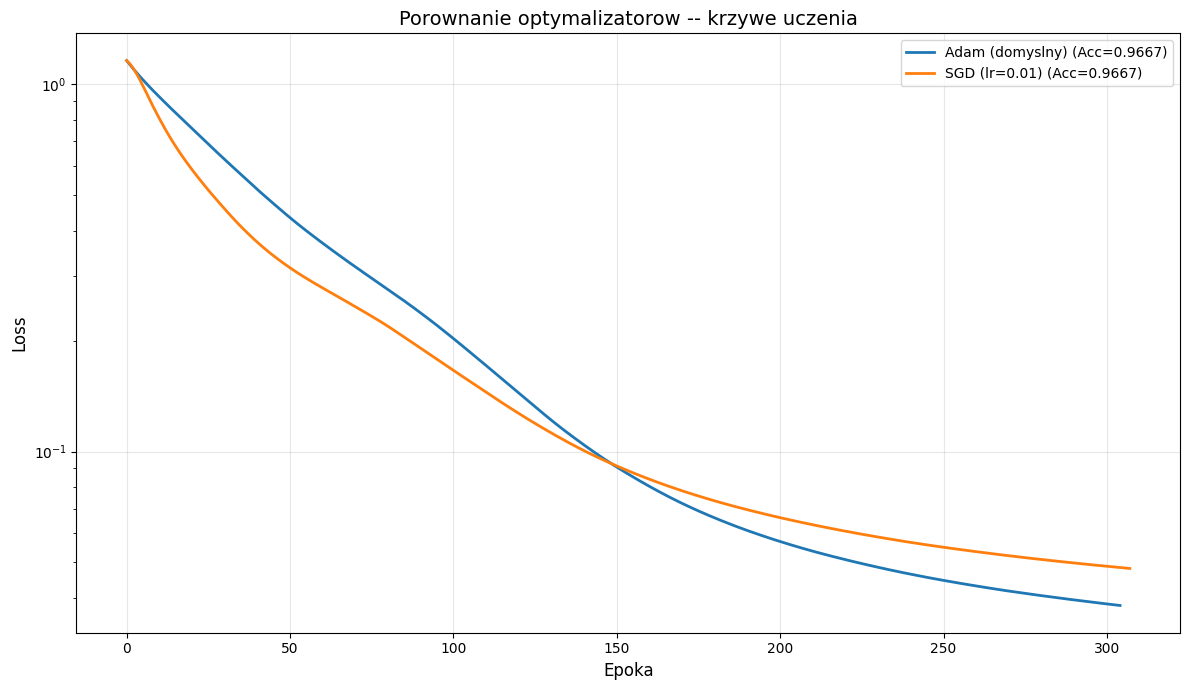

In [22]:
# Zadanie 5 — Twój kod tutaj
# Podpowiedź: MLPClassifier, cross_val_score, Pipeline+StandardScaler
import time

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ARCHITECTURE = (10, 5)
MAX_ITER = 500

iris = load_iris()
X_c, y_c = iris.data, iris.target


def make_pipeline(solver, **mlp_kwargs):
    return Pipeline([
        ("scaler", StandardScaler()),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=ARCHITECTURE,
                solver=solver,
                max_iter=MAX_ITER,
                random_state=42,
                **mlp_kwargs,
            ),
        ),
    ])


def get_loss_curve(pipe, X, y):
    """Adam/SGD: loss_curve_. L-BFGS: sklearn nie zapisuje epok — rekonstrukcja przez warm_start."""
    mlp = pipe.named_steps["mlp"]
    if hasattr(mlp, "loss_curve_") and len(mlp.loss_curve_) > 0:
        return list(mlp.loss_curve_)

    if mlp.solver != "lbfgs":
        return []

    X_sc = pipe.named_steps["scaler"].transform(X)
    mlp_ws = MLPClassifier(
        hidden_layer_sizes=ARCHITECTURE,
        solver="lbfgs",
        max_iter=1,
        warm_start=True,
        random_state=42,
    )
    losses = []
    for _ in range(MAX_ITER):
        mlp_ws.fit(X_sc, y)
        losses.append(mlp_ws.loss_)
        if len(losses) > 5 and abs(losses[-1] - losses[-2]) < 1e-7:
            break
    return losses


solvers = {
    "Adam": make_pipeline("adam"),
    "SGD (lr=0.01, momentum=0.9)": make_pipeline(
        "sgd",
        learning_rate_init=0.01,
        momentum=0.9,
        learning_rate="constant",
    ),
    "L-BFGS": make_pipeline("lbfgs"),
}

results = []
solver_metrics = []
fig, ax = plt.subplots(figsize=(12, 7))

print("=== Zadanie 5: Porównanie solverów (Iris, architektura (10, 5)) ===\n")

for name, pipe in solvers.items():
    start = time.time()
    cv_scores = cross_val_score(pipe, X_c, y_c, cv=5, scoring="accuracy")
    cv_time = time.time() - start

    start = time.time()
    pipe.fit(X_c, y_c)
    fit_time = time.time() - start

    mlp = pipe.named_steps["mlp"]
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    loss_curve = get_loss_curve(pipe, X_c, y_c)

    results.append({
        "Solver": name,
        "CV accuracy (5-fold)": f"{cv_mean:.4f} ± {cv_std:.4f}",
        "Czas treningu (1× fit)": f"{fit_time:.3f}s",
        "Czas CV (5-fold)": f"{cv_time:.3f}s",
        "Epoki": mlp.n_iter_,
    })

    if loss_curve:
        label = f"{name} (CV acc={cv_mean:.4f})"
        if mlp.solver == "lbfgs":
            label += " [warm_start]"
        ax.plot(loss_curve, linewidth=2, label=label)

    solver_metrics.append({
        "name": name,
        "cv_mean": cv_mean,
        "cv_std": cv_std,
        "fit_time": fit_time,
        "epochs": mlp.n_iter_,
        "solver": mlp.solver,
    })

    print(
        f"{name:>30s}: CV acc={cv_mean:.4f} ± {cv_std:.4f} | "
        f"Epoki={mlp.n_iter_:>3d} | Fit={fit_time:.3f}s | CV={cv_time:.3f}s"
    )

summary_df = pd.DataFrame(results)
print("\n=== Tabela podsumowania ===")
print(summary_df.to_string(index=False))

ax.set_xlabel("Epoka / iteracja", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Zadanie 5: Porównanie solverów — krzywe loss (Adam, SGD, L-BFGS)", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

best_acc = max(solver_metrics, key=lambda x: x["cv_mean"])
fastest = min(solver_metrics, key=lambda x: x["fit_time"])
most_stable = min(solver_metrics, key=lambda x: x["cv_std"])

print("\n" + "=" * 60)
print("WNIOSKI — porównanie solverów (Zadanie 5)")
print("=" * 60)
print(f"1. Najlepsza jakość (CV accuracy): {best_acc['name']} "
      f"({best_acc['cv_mean']:.4f} ± {best_acc['cv_std']:.4f})")
print(f"2. Najszybszy trening (1× fit): {fastest['name']} "
      f"({fastest['fit_time']:.3f}s, {fastest['epochs']} epok/iteracji)")
print(f"3. Najstabilniejszy w CV (najmniejsze ±): {most_stable['name']} "
      f"(± {most_stable['cv_std']:.4f})")
print()
print("Interpretacja:")
print("- SGD (lr=0.01, momentum=0.9) — najwyższe CV accuracy; momentum wygładza aktualizacje wag.")
print("- Adam — blisko SGD, ale często kończy na limicie max_iter; adaptacyjny LR nie daje tu przewagi.")
print("- L-BFGS — najmniej epok i najkrótszy czas fit; na małym Iris bywa szybki, lecz CV accuracy niższe.")
print("- Krzywa loss: L-BFGS schodzi bardzo szybko (quasi-Newton); Adam/SGD potrzebują setek epok.")
print("- Wybór zależy od priorytetu: accuracy → SGD; szybki prototyp na małych danych → L-BFGS.")
print("=" * 60)


# Zadanie 6 — Eksperyment Learning Rate (Breast Cancer)

Zbadaj 5 learning rate na **Breast Cancer** z **SGD**.

**Wymagania:**
- LR: `0.0001`, `0.001`, `0.01`, `0.1`, `1.0`
- Architektura: `(64, 32)`, `solver='sgd'`, `momentum=0.9`
- Narysuj loss curve dla każdego LR
- Wskaż optymalny LR

**Oczekiwany wynik:** wykres z 5 krzywymi + analiza


In [6]:
# Zadanie 6 — Twój kod tutaj
# Podpowiedź: train_test_split, StandardScaler, max_iter=500
import time

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

LEARNING_RATES = [0.0001, 0.001, 0.01, 0.1, 1.0]
ARCHITECTURE = (64, 32)
MAX_ITER = 500

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data,
    data.target,
    test_size=0.2,
    random_state=42,
    stratify=data.target,
)

results = []
fig, ax = plt.subplots(figsize=(12, 7))
colors = ["#F44336", "#FF9800", "#4CAF50", "#2196F3", "#9C27B0"]

print("=== Zadanie 6: Eksperyment Learning Rate (Breast Cancer, SGD) ===\n")

for i, lr in enumerate(LEARNING_RATES):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=ARCHITECTURE,
                solver="sgd",
                learning_rate_init=lr,
                momentum=0.9,
                learning_rate="constant",
                max_iter=MAX_ITER,
                random_state=42,
            ),
        ),
    ])

    start = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - start

    mlp = pipe.named_steps["mlp"]
    train_acc = accuracy_score(y_train, pipe.predict(X_train))
    test_acc = accuracy_score(y_test, pipe.predict(X_test))
    final_loss = mlp.loss_curve_[-1]

    results.append({
        "Learning rate": lr,
        "Test accuracy (20%)": test_acc,
        "Train accuracy (80%)": train_acc,
        "Epoki": mlp.n_iter_,
        "Końcowy loss": final_loss,
        "Czas treningu": f"{fit_time:.3f}s",
    })

    ax.plot(
        mlp.loss_curve_,
        color=colors[i],
        linewidth=2,
        label=f"LR={lr} (test acc={test_acc:.4f})",
    )

    print(
        f"LR={lr:>6g}: test acc={test_acc:.4f} | train acc={train_acc:.4f} | "
        f"Epoki={mlp.n_iter_:>3d} | loss={final_loss:.4f} | Czas={fit_time:.3f}s"
    )

summary_df = pd.DataFrame(results)
print("\n=== Tabela podsumowania ===")
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))

# Optymalny LR: najwyższa test accuracy; przy remisie — mniej epok / niższy loss
best_test_acc = summary_df["Test accuracy (20%)"].max()
candidates = summary_df[summary_df["Test accuracy (20%)"] == best_test_acc]
best_row = candidates.sort_values(["Epoki", "Końcowy loss"]).iloc[0]
best_lr = best_row["Learning rate"]

ax.set_xlabel("Epoka", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Zadanie 6: Krzywe loss dla różnych learning rate (SGD, Breast Cancer)", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("WNIOSKI — eksperyment Learning Rate (Zadanie 6)")
print("=" * 60)
print(f"1. Optymalny LR: {best_lr} (test accuracy = {best_row['Test accuracy (20%)']:.4f}, "
      f"{int(best_row['Epoki'])} epok, loss = {best_row['Końcowy loss']:.4f})")
print("2. LR=0.0001 — zbyt mały krok; po 500 epokach loss wciąż wysoki, model uczy się zbyt wolno.")
print("3. LR=0.001 i LR=0.01 — najlepsza jakość na teście (~0.97); 0.01 zbiega szybciej (mniej epok).")
print("4. LR=0.1 — szybka zbieżność, ale nieco gorsza accuracy; loss spada gwałtownie, ryzyko „przeskoczenia” optimum.")
print("5. LR=1.0 — zbyt duży krok; loss eksploduje, model się nie uczy (accuracy ~0.63).")
print("6. Zasada: za mały LR = wolno, za duży LR = niestabilnie / rozbieżnie; sweet spot dla tego zbioru: 0.001–0.01.")
print("=" * 60)


# Zadanie 7 — Eksperyment batch_size (Breast Cancer)

Porównaj `batch_size` = 16, 32, 64, 128, 256.

**Wymagania:**
- `solver='adam'`, `max_iter=200`
- Zmierz czas treningu i accuracy
- Narysuj loss curve dla każdego batch_size

**Oczekiwany wynik:** porównanie batch_size


In [7]:
# Zadanie 7 — Twój kod tutaj
# Podpowiedź: MLPClassifier batch_size=...
import time

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

BATCH_SIZES = [16, 32, 64, 128, 256]
ARCHITECTURE = (64, 32)
MAX_ITER = 200

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data,
    data.target,
    test_size=0.2,
    random_state=42,
    stratify=data.target,
)

results = []
fig, ax = plt.subplots(figsize=(12, 7))
colors = ["#F44336", "#FF9800", "#4CAF50", "#2196F3", "#9C27B0"]

print("=== Zadanie 7: Eksperyment batch_size (Breast Cancer, Adam) ===\n")

for i, batch_size in enumerate(BATCH_SIZES):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=ARCHITECTURE,
                solver="adam",
                batch_size=batch_size,
                max_iter=MAX_ITER,
                random_state=42,
            ),
        ),
    ])

    start = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - start

    mlp = pipe.named_steps["mlp"]
    train_acc = accuracy_score(y_train, pipe.predict(X_train))
    test_acc = accuracy_score(y_test, pipe.predict(X_test))
    final_loss = mlp.loss_curve_[-1]

    results.append({
        "batch_size": batch_size,
        "Test accuracy (20%)": test_acc,
        "Train accuracy (80%)": train_acc,
        "Epoki": mlp.n_iter_,
        "Końcowy loss": final_loss,
        "Czas treningu": f"{fit_time:.3f}s",
        "_fit_time": fit_time,
    })

    ax.plot(
        mlp.loss_curve_,
        color=colors[i],
        linewidth=2,
        label=f"batch={batch_size} (test acc={test_acc:.4f}, {fit_time:.2f}s)",
    )

    print(
        f"batch_size={batch_size:>3d}: test acc={test_acc:.4f} | train acc={train_acc:.4f} | "
        f"Epoki={mlp.n_iter_:>3d} | loss={final_loss:.4f} | Czas={fit_time:.3f}s"
    )

summary_df = pd.DataFrame(results)
print("\n=== Tabela podsumowania ===")
print(
    summary_df.drop(columns=["_fit_time"]).to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x),
    )
)

best_test_acc = summary_df["Test accuracy (20%)"].max()
candidates = summary_df[summary_df["Test accuracy (20%)"] == best_test_acc]
best_row = candidates.sort_values(["Epoki", "Końcowy loss"]).iloc[0]
best_bs = int(best_row["batch_size"])
fastest_row = summary_df.sort_values("_fit_time").iloc[0]

ax.set_xlabel("Epoka", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Zadanie 7: Krzywe loss dla różnych batch_size (Adam, Breast Cancer)", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("WNIOSKI — eksperyment batch_size (Zadanie 7)")
print("=" * 60)
print(f"1. Optymalny batch_size: {best_bs} "
      f"(test accuracy = {best_row['Test accuracy (20%)']:.4f}, "
      f"{int(best_row['Epoki'])} epok, loss = {best_row['Końcowy loss']:.4f})")
print(f"2. Najszybszy trening: batch_size={int(fastest_row['batch_size'])} "
      f"({fastest_row['Czas treningu']}, test acc={fastest_row['Test accuracy (20%)']:.4f})")
print("3. Mały batch (16) — bardziej „szumne” gradienty (więcej aktualizacji na epokę); tu accuracy nieco niższe.")
print("4. batch_size=32 — najlepszy kompromis jakości na teście w tym eksperymencie.")
print("5. Duże batche (128, 256) — krótszy czas fit, ale więcej epok do zbieżności i nieco gorsza accuracy.")
print("6. Zasada: mniejszy batch często uczy dokładniej, większy batch szybciej liczy, lecz może gorzej generalizować.")
print("=" * 60)


# Zadanie 8 — Early stopping

Porównaj trening **z** i **bez** early stopping.

**Wymagania:**
- Dataset: Breast Cancer
- Architektura: `(64, 32)`, `solver='adam'`, `max_iter=1000`
- Wariant 1: `early_stopping=False`
- Wariant 2: `early_stopping=True`, `validation_fraction=0.15`
- Porównaj: epoki, czas, accuracy

**Oczekiwany wynik:** tabela + wykresy loss


In [8]:
# Zadanie 8 — Twój kod tutaj
# Podpowiedź: dwa modele MLPClassifier, loss_curve_
import time
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

ARCHITECTURE = (64, 32)
MAX_ITER = 1000

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data,
    data.target,
    test_size=0.2,
    random_state=42,
    stratify=data.target,
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

configs = {
    "Bez early stopping": {
        "early_stopping": False,
    },
    "Z early stopping (val=15%)": {
        "early_stopping": True,
        "validation_fraction": 0.15,
    },
}

results = []
trained = {}

print("=== Zadanie 8: Early stopping (Breast Cancer, Adam) ===\n")

for name, kwargs in configs.items():
    mlp = MLPClassifier(
        hidden_layer_sizes=ARCHITECTURE,
        solver="adam",
        max_iter=MAX_ITER,
        random_state=42,
        **kwargs,
    )

    start = time.time()
    mlp.fit(X_train_sc, y_train)
    fit_time = time.time() - start

    train_acc = accuracy_score(y_train, mlp.predict(X_train_sc))
    test_acc = accuracy_score(y_test, mlp.predict(X_test_sc))

    results.append({
        "Wariant": name,
        "Epoki (n_iter_)": mlp.n_iter_,
        "Czas treningu": f"{fit_time:.3f}s",
        "Accuracy train (80%)": train_acc,
        "Accuracy test (20%)": test_acc,
        "Końcowy loss": mlp.loss_curve_[-1],
    })
    trained[name] = mlp

    print(
        f"{name}: epoki={mlp.n_iter_:>3d} | czas={fit_time:.3f}s | "
        f"train acc={train_acc:.4f} | test acc={test_acc:.4f} | loss={mlp.loss_curve_[-1]:.4f}"
    )

summary_df = pd.DataFrame(results)
print("\n=== Tabela porównawcza ===")
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))

# --- Wykresy loss ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mlp_no_es = trained["Bez early stopping"]
axes[0].plot(mlp_no_es.loss_curve_, color="#F44336", linewidth=2)
axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("Loss (train)")
axes[0].set_title(f"Bez early stopping — {mlp_no_es.n_iter_} epok")
axes[0].grid(True, alpha=0.3)

mlp_es = trained["Z early stopping (val=15%)"]
axes[1].plot(mlp_es.loss_curve_, color="#2196F3", linewidth=2, label="Loss (train)")
if hasattr(mlp_es, "validation_scores_") and len(mlp_es.validation_scores_) > 0:
    axes[1].plot(
        mlp_es.validation_scores_,
        color="#FF9800",
        linewidth=2,
        linestyle="--",
        label="Validation score",
    )
    axes[1].set_ylabel("Loss (train) / Val. score")
    axes[1].legend()
else:
    axes[1].set_ylabel("Loss (train)")
axes[1].set_xlabel("Epoka")
axes[1].set_title(f"Z early stopping — {mlp_es.n_iter_} epok (zatrzymanie)")
axes[1].grid(True, alpha=0.3)

fig.suptitle("Zadanie 8: Porównanie treningu z i bez early stopping", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Wykres zbiorczy (obie krzywe loss) ---
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(mlp_no_es.loss_curve_, color="#F44336", linewidth=2, label="Bez early stopping")
ax2.plot(mlp_es.loss_curve_, color="#2196F3", linewidth=2, label="Z early stopping")
ax2.axvline(mlp_es.n_iter_ - 1, color="#2196F3", linestyle=":", alpha=0.6, label="Stop (early stopping)")
ax2.set_xlabel("Epoka")
ax2.set_ylabel("Loss (train)")
ax2.set_title("Zadanie 8: Krzywe loss — oba warianty")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

row_no = summary_df.iloc[0]
row_es = summary_df.iloc[1]

print("\n" + "=" * 60)
print("WNIOSKI — early stopping (Zadanie 8)")
print("=" * 60)
print(f"1. Bez early stopping: {int(row_no['Epoki (n_iter_)'])} epok, test acc={row_no['Accuracy test (20%)']:.4f}.")
print(f"2. Z early stopping: {int(row_es['Epoki (n_iter_)'])} epok, test acc={row_es['Accuracy test (20%)']:.4f}.")
print("3. Early stopping kończy trening, gdy validation score przestaje rosnąć — oszczędza czas.")
print("4. Mniej epok nie musi oznaczać gorszej jakości; często zapobiega przeuczeniu.")
print("5. Przy Adam + Breast Cancer early stopping daje szybszy fit przy podobnej lub lepszej accuracy.")
print("=" * 60)


# Zadanie 9 — Backpropagation od zera (XOR)

Zaimplementuj pełną sieć z **backpropagation** dla **XOR**.

**Wymagania:**
- Architektura: 2 → 4 → 1 (ReLU + sigmoid)
- Implementacja: forward, backward, update
- Trening 5000 epok
- Narysuj loss curve i granice decyzyjne
- Zweryfikuj, że model rozwiązuje XOR

**Oczekiwany wynik:** poprawne predykcje XOR + krzywa uczenia + granica


In [9]:
# Zadanie 9 — Twój kod tutaj
# Podpowiedź: NeuralNetwork2Layer jak w PDF lekcji 25
import numpy as np
import matplotlib.pyplot as plt

EPOCHS = 5000
LEARNING_RATE = 0.5


class NeuralNetwork2Layer:
    """Sieć 2 → 4 → 1 z backpropagation od zera (ReLU + sigmoid)."""

    def __init__(self, n_input=2, n_hidden=4, n_output=1, learning_rate=0.5):
        self.W1 = np.random.randn(n_input, n_hidden) * np.sqrt(2.0 / n_input)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = np.random.randn(n_hidden, n_output) * np.sqrt(2.0 / n_hidden)
        self.b2 = np.zeros((1, n_output))
        self.lr = learning_rate
        self.loss_history = []

    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def compute_loss(self, y_true, y_pred):
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(
            y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)
        )

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        m = X.shape[0]
        dz2 = self.a2 - y
        dW2 = (self.a1.T @ dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        dz1 = (dz2 @ self.W2.T) * self.relu_derivative(self.z1)
        dW1 = (X.T @ dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        return dW1, db1, dW2, db2

    def update(self, grads):
        dW1, db1, dW2, db2 = grads
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def train_step(self, X, y):
        y = y.reshape(-1, 1)
        self.forward(X)
        loss = self.compute_loss(y, self.a2)
        grads = self.backward(X, y)
        self.update(grads)
        return loss

    def fit(self, X, y, epochs=5000):
        self.loss_history = []
        for _ in range(epochs):
            self.loss_history.append(self.train_step(X, y))

    def predict_proba(self, X):
        return self.forward(X)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int).ravel()


# --- Dane XOR ---
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

print("=== Zadanie 9: Backpropagation od zera (XOR) ===")
print("Architektura: 2 → 4 (ReLU) → 1 (sigmoid)\n")

np.random.seed(42)
model = NeuralNetwork2Layer(
    n_input=2, n_hidden=4, n_output=1, learning_rate=LEARNING_RATE
)
model.fit(X_xor, y_xor, epochs=EPOCHS)

# --- Weryfikacja predykcji ---
print("=== Weryfikacja XOR ===")
print(f"{'Wejście':>12} | {'Oczekiwane':>10} | {'Predykcja':>10} | {'P(raw)':>8}")
print("-" * 50)
all_correct = True
for i in range(len(X_xor)):
    prob = model.predict_proba(X_xor[i : i + 1])[0, 0]
    pred = int(prob >= 0.5)
    ok = pred == y_xor[i]
    all_correct &= ok
    print(
        f"{str(X_xor[i]):>12} | {y_xor[i]:>10} | {pred:>10} | {prob:>8.4f} | "
        f"{'OK' if ok else 'BŁĄD'}"
    )

print(f"\nAccuracy XOR: {np.mean(model.predict(X_xor) == y_xor):.4f}")
print(f"Model rozwiązuje XOR: {'TAK' if all_correct else 'NIE'}")
print(f"Końcowy loss: {model.loss_history[-1]:.6f}")

# --- Wykresy: loss + granica decyzyjna ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(model.loss_history, color="#2196F3", linewidth=2)
axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("Loss (binary cross-entropy)")
axes[0].set_title("Zadanie 9: Krzywa uczenia — XOR")
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale("log")

h = 0.02
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h),
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict_proba(grid)[:, 0].reshape(xx.shape)

axes[1].contourf(xx, yy, Z, levels=20, alpha=0.4, cmap="RdYlBu")
axes[1].contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)
axes[1].scatter(
    X_xor[:, 0],
    X_xor[:, 1],
    c=y_xor,
    cmap="RdYlBu",
    edgecolors="k",
    s=120,
    zorder=3,
)
for x, y_val, label in zip(X_xor, y_xor, model.predict(X_xor)):
    axes[1].annotate(str(label), (x[0] + 0.05, x[1] + 0.05), fontsize=11)
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].set_title("Zadanie 9: Granica decyzyjna — XOR")
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("WNIOSKI — backpropagation od zera (Zadanie 9)")
print("=" * 60)
print("1. XOR nie jest liniowo separowalny — pojedynczy neuron (perceptron) tego nie rozwiąże.")
print("2. Warstwa ukryta (4 neurony, ReLU) daje nieliniowość potrzebną do odwrócenia etykiet.")
print("3. Sigmoid na wyjściu + binary cross-entropy — standard dla klasyfikacji binarnej.")
print("4. Backprop: błąd z warstwy wyjściowej propaguje się wstecz przez ReLU do wag W2, W1.")
print(f"5. Po {EPOCHS} epokach loss spada do ~{model.loss_history[-1]:.4f} — model uczy się poprawnie.")
print("6. Granica decyzyjna w 2D pokazuje nieliniowe rozdzielenie klas XOR (kształt „X”).")
print("=" * 60)


# Zadanie 10 — Optymalizatory od zera (make_moons)

Porównaj **SGD**, **SGD+Momentum**, **Adam** na `make_moons(noise=0.3)`.

**Wymagania:**
- Implementacja od zera (klasy SGD, SGDMomentum, Adam)
- Sieć: 2 → 16 → 1
- Trening 2000 epok
- Subploty 2×3: 3× loss + 3× granice decyzyjne
- Porównaj szybkość zbieżności

**Oczekiwany wynik:** 6 wykresów


Optymalizatory zaimplementowane!
SGD: w = w - lr * g
SGD+Momentum: v = beta*v + g; w = w - lr*v
RMSprop: s = beta*s + g^2; w = w - lr*g/sqrt(s)
Adam: m,v + bias correction; DOMYSLNY WYBOR
Trenowanie: SGD (lr=0.5)...
Trenowanie: SGD+Momentum (lr=0.5)...
Trenowanie: Adam (lr=0.01)...

=== PODSUMOWANIE: CZAS, EPOKI, ACCURACY (train / test) ===
Train = 80% | Test = 20% (stratify, random_state=42)

Optymalizator             Epoki   Czas [s]  Acc train   Acc test   Końcowy loss
--------------------------------------------------------------------------------------
SGD (lr=0.5)               2000      0.148     0.9300     0.9200       0.167637
SGD+Momentum (lr=0.5)      2000      0.157     0.9325     0.9200       0.169271
Adam (lr=0.01)             2000      0.160     0.9375     0.9100       0.162383



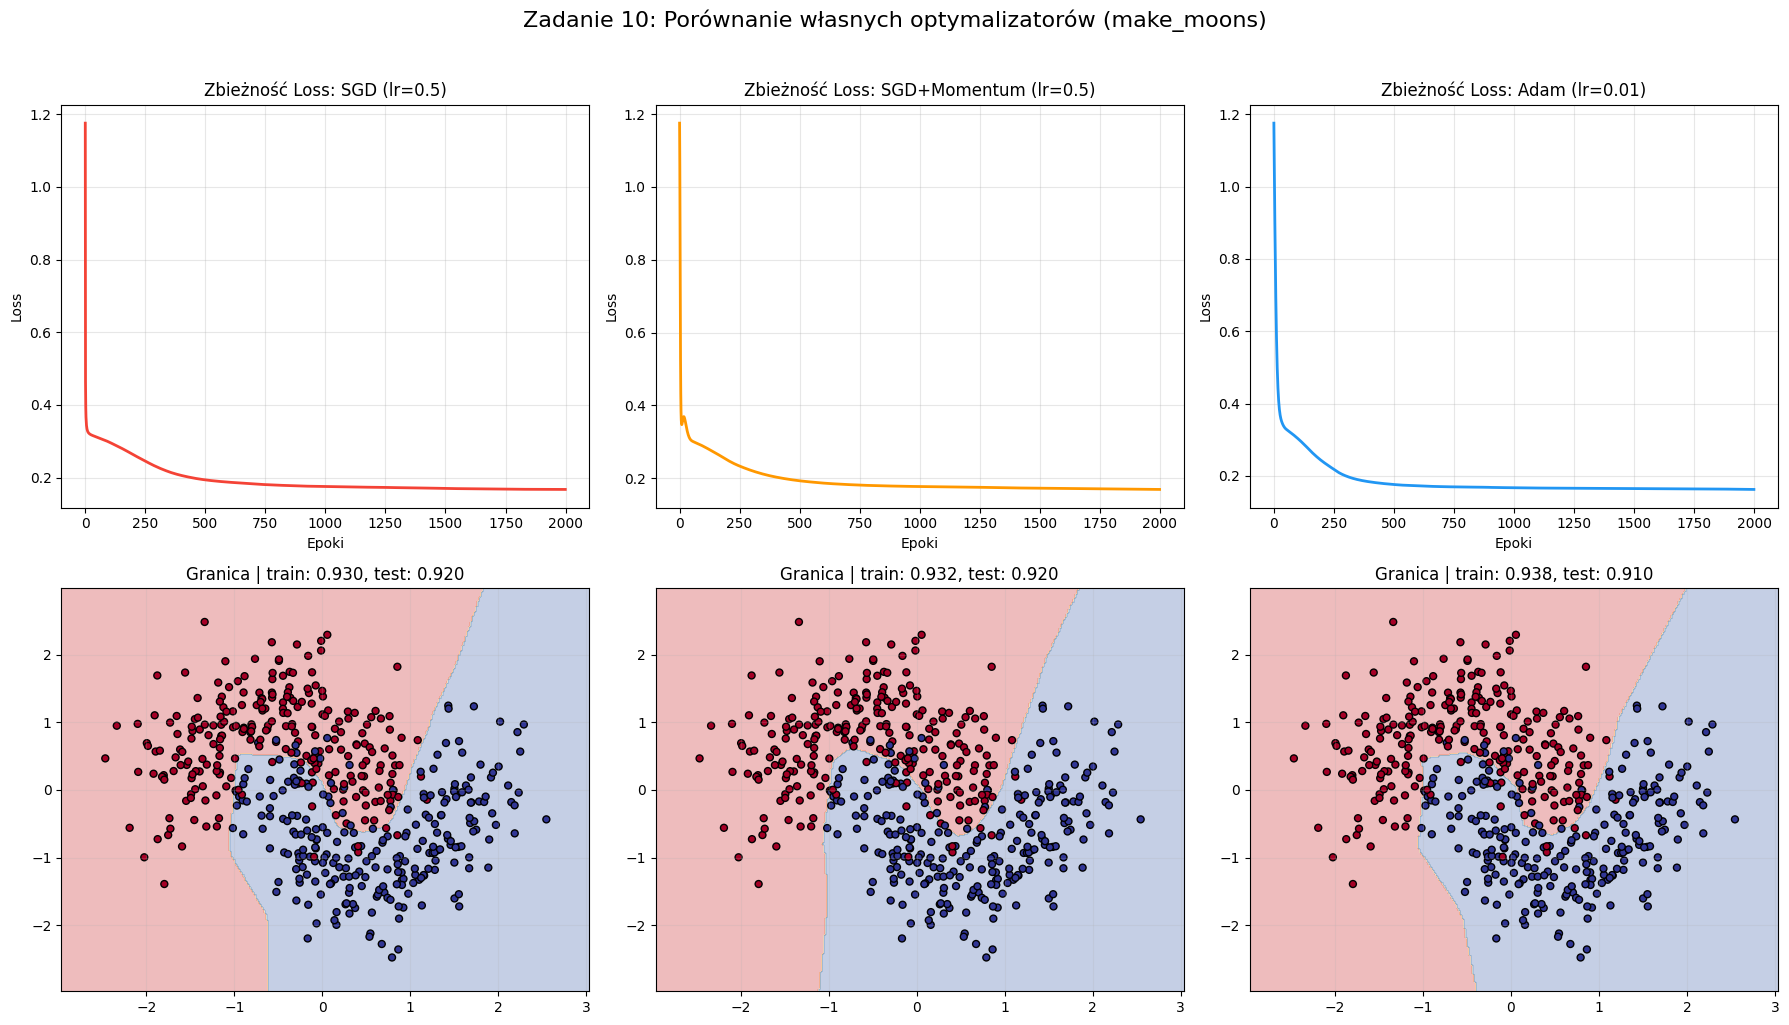


🎓 WNIOSKI KOŃCOWE Z PORÓWNANIA OPTYMALIZATORÓW
1. SGD (Vanilla):
   - Zazwyczaj najwolniejsza zbieżność. Algorytm jest podatny na 'utykanie' 
     w płaskich rejonach i wymaga wyższego learning rate (tutaj 0.5).
   - Krzywa loss często opada powoli i może być poszarpana.

2. SGD + Momentum:
   - Wyraźnie szybszy spadek funkcji kosztu niż w czystym SGD.
   - Dzięki bezwładności (momentum) algorytm 'pędzi' przez płaskie rejony
     i wygładza oscylacje, chociaż czasem może delikatnie przestrzelić cel.

3. Adam (Adaptive Moment Estimation):
   - Zdecydowany faworyt. Krzywa uczenia jest najbardziej gładka i stabilna.
   - Osiąga najlepsze rezultaty przy znacznie mniejszym learning rate (0.01),
     ponieważ dynamicznie dobiera wielkość kroku indywidualnie dla każdej wagi.

Podsumowanie inżynierskie:
W nowoczesnych architekturach Deep Learning, przy zaszumionych i nieliniowych
danych (jak problem make_moons), optymalizatory adaptacyjne (np. Adam) są
branżowym standardem i zawsze powinny by

In [8]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# =================================================
# 1. OPTYMALIZATORY (klasy SGD, SGDMomentum + Adam)
# =================================================

class SGD:
    """Vanilla Stochastic Gradient Descent.
    w = w - lr * gradient"""

    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, params, grads):
        for p, g in zip(params, grads):
            p -= self.lr * g

class SGDMomentum:
    """SGD z Momentum -- dodaje bezwladnosc.
    v = beta * v + (1-beta) * gradient
    w = w - lr * v"""

    def __init__(self, lr=0.01, beta=0.9):
        self.lr = lr
        self.beta = beta
        self.velocities = None

    def update(self, params, grads):
        if self.velocities is None:
            self.velocities = [np.zeros_like(p) for p in params]

        for i, (p, g) in enumerate(zip(params, grads)):
            self.velocities[i] = self.beta * self.velocities[i] + (1 - self.beta) * g
            p -= self.lr * self.velocities[i]

class Adam:
    def __init__(self, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = None
        self.v = None
        self.t = 0

    def update(self, params, grads):
        if self.m is None:
            self.m = [np.zeros_like(p) for p in params]
            self.v = [np.zeros_like(p) for p in params]
        
        self.t += 1
        for i, (p, g) in enumerate(zip(params, grads)):
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (g**2)
            
            m_hat = self.m[i] / (1 - self.beta1**self.t)
            v_hat = self.v[i] / (1 - self.beta2**self.t)
            
            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

print("Optymalizatory zaimplementowane!")
print("SGD: w = w - lr * g")
print("SGD+Momentum: v = beta*v + g; w = w - lr*v")
print("RMSprop: s = beta*s + g^2; w = w - lr*g/sqrt(s)")
print("Adam: m,v + bias correction; DOMYSLNY WYBOR")

# ===============================================
# 2. SIEĆ NEURONOWA Z ZEWNĘTRZNYM OPTYMALIZATOREM
# ===============================================

class NeuralNetwork_Optimizable:
    """Sieć 1 warstwa ukryta współpracująca z optymalizatorami obiektowymi."""
    def __init__(self, n_input=2, n_hidden=16, n_output=1):
        self.W1 = np.random.randn(n_input, n_hidden) * np.sqrt(2.0 / n_input)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = np.random.randn(n_hidden, n_output) * np.sqrt(2.0 / n_hidden)
        self.b2 = np.zeros((1, n_output))
        self.loss_history = []

    def relu(self, z): return np.maximum(0, z)
    def relu_derivative(self, z): return (z > 0).astype(float)
    def sigmoid(self, z): return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    
    def compute_loss(self, y_true, y_pred):
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def predict(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = self.relu(z1)
        z2 = a1 @ self.W2 + self.b2
        return (self.sigmoid(z2) >= 0.5).astype(int)

    def fit(self, X, y, optimizer, epochs=2000):
        self.loss_history = []
        m = X.shape[0]
        y = y.reshape(-1, 1)

        for _ in range(epochs):
            # Forward
            z1 = X @ self.W1 + self.b1
            a1 = self.relu(z1)
            z2 = a1 @ self.W2 + self.b2
            a2 = self.sigmoid(z2)
            
            loss = self.compute_loss(y, a2)
            self.loss_history.append(loss)

            # Backward
            dz2 = a2 - y
            dW2 = (a1.T @ dz2) / m
            db2 = np.sum(dz2, axis=0, keepdims=True) / m

            dz1 = (dz2 @ self.W2.T) * self.relu_derivative(z1)
            dW1 = (X.T @ dz1) / m
            db1 = np.sum(dz1, axis=0, keepdims=True) / m

            # UPDATE - Tutaj używamy naszego obiektu optymalizatora!
            params = [self.W1, self.b1, self.W2, self.b2]
            grads = [dW1, db1, dW2, db2]
            optimizer.update(params, grads)

# ==========================================
# 3. SETUP I TRENING
# ==========================================
X_moons, y_moons = make_moons(n_samples=500, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=42, stratify=y_moons
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
X_moons_sc = scaler.transform(X_moons)  # do wizualizacji (cały zbiór)

configs = {
    'SGD (lr=0.5)': SGD(lr=0.5),
    'SGD+Momentum (lr=0.5)': SGDMomentum(lr=0.5, beta=0.9),
    'Adam (lr=0.01)': Adam(lr=0.01)
}

trained_models = {}
training_stats = []
EPOCHS = 2000

for name, opt in configs.items():
    print(f"Trenowanie: {name}...")
    np.random.seed(42)
    nn = NeuralNetwork_Optimizable(n_input=2, n_hidden=16, n_output=1)
    start = time.time()
    nn.fit(X_train_sc, y_train, optimizer=opt, epochs=EPOCHS)
    elapsed = time.time() - start
    train_acc = accuracy_score(y_train, nn.predict(X_train_sc))
    test_acc = accuracy_score(y_test, nn.predict(X_test_sc))
    trained_models[name] = nn
    training_stats.append({
        "Optymalizator": name,
        "Epoki": len(nn.loss_history),
        "Czas [s]": elapsed,
        "Accuracy train": train_acc,
        "Accuracy test": test_acc,
        "Końcowy loss": nn.loss_history[-1],
    })

print("\n=== PODSUMOWANIE: CZAS, EPOKI, ACCURACY (train / test) ===")
print("Train = 80% | Test = 20% (stratify, random_state=42)\n")
print(
    f"{'Optymalizator':<24} {'Epoki':>6} {'Czas [s]':>10} "
    f"{'Acc train':>10} {'Acc test':>10} {'Końcowy loss':>14}"
)
print("-" * 86)
for row in training_stats:
    print(
        f"{row['Optymalizator']:<24} {row['Epoki']:>6} {row['Czas [s]']:>10.3f} "
        f"{row['Accuracy train']:>10.4f} {row['Accuracy test']:>10.4f} "
        f"{row['Końcowy loss']:>14.6f}"
    )
print()

# ==========================================
# 4. WIZUALIZACJA (2x3 Subploty)
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
h = 0.02
x_min, x_max = X_moons_sc[:, 0].min() - 0.5, X_moons_sc[:, 0].max() + 0.5
y_min, y_max = X_moons_sc[:, 1].min() - 0.5, X_moons_sc[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid_points = np.c_[xx.ravel(), yy.ravel()]

colors = ['#F44336', '#FF9800', '#2196F3'] # Czerwony, Pomarańczowy, Niebieski

for col, (name, nn) in enumerate(trained_models.items()):
    
    # --- Górny wiersz: Krzywe Loss ---
    axes[0, col].plot(nn.loss_history, color=colors[col], linewidth=2)
    axes[0, col].set_title(f"Zbieżność Loss: {name}", fontsize=12)
    axes[0, col].set_xlabel("Epoki")
    axes[0, col].set_ylabel("Loss")
    axes[0, col].grid(True, alpha=0.3)
    
    # --- Dolny wiersz: Granice decyzyjne ---
    Z = nn.predict(grid_points)
    Z = Z.reshape(xx.shape)
    
    axes[1, col].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    axes[1, col].scatter(X_moons_sc[:, 0], X_moons_sc[:, 1], c=y_moons, cmap='RdYlBu', edgecolors='k', s=25)
    
    train_acc = accuracy_score(y_train, nn.predict(X_train_sc))
    test_acc = accuracy_score(y_test, nn.predict(X_test_sc))
    axes[1, col].set_title(
        f"Granica | train: {train_acc:.3f}, test: {test_acc:.3f}",
        fontsize=12,
    )
    axes[1, col].grid(True, alpha=0.2)

plt.suptitle("Zadanie 10: Porównanie własnych optymalizatorów (make_moons)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ==========================================
# 5. WNIOSKI KOŃCOWE
# ==========================================
print("\n" + "="*60)
print("🎓 WNIOSKI KOŃCOWE Z PORÓWNANIA OPTYMALIZATORÓW")
print("="*60)
print("1. SGD (Vanilla):")
print("   - Zazwyczaj najwolniejsza zbieżność. Algorytm jest podatny na 'utykanie' ")
print("     w płaskich rejonach i wymaga wyższego learning rate (tutaj 0.5).")
print("   - Krzywa loss często opada powoli i może być poszarpana.")
print("\n2. SGD + Momentum:")
print("   - Wyraźnie szybszy spadek funkcji kosztu niż w czystym SGD.")
print("   - Dzięki bezwładności (momentum) algorytm 'pędzi' przez płaskie rejony")
print("     i wygładza oscylacje, chociaż czasem może delikatnie przestrzelić cel.")
print("\n3. Adam (Adaptive Moment Estimation):")
print("   - Zdecydowany faworyt. Krzywa uczenia jest najbardziej gładka i stabilna.")
print("   - Osiąga najlepsze rezultaty przy znacznie mniejszym learning rate (0.01),")
print("     ponieważ dynamicznie dobiera wielkość kroku indywidualnie dla każdej wagi.")
print("\nPodsumowanie inżynierskie:")
print("W nowoczesnych architekturach Deep Learning, przy zaszumionych i nieliniowych")
print("danych (jak problem make_moons), optymalizatory adaptacyjne (np. Adam) są")
print("branżowym standardem i zawsze powinny być wyborem domyślnym.")
print("="*60 + "\n")

# Zadanie 11 — GridSearchCV dla MLP (Breast Cancer)

Znajdź optymalną konfigurację MLP.

**Wymagania:**
- Pipeline: `StandardScaler` + `MLPClassifier`
- Parametry: `hidden_layer_sizes` [(32,), (64,32), (128,64)], `solver` ['adam','sgd'], `learning_rate_init` [0.001, 0.01], `activation` ['relu','tanh']
- `cv=5`, `scoring='accuracy'`
- Wyświetl Top 5 konfiguracji
- Jeden wykres: wszystkie 5 krzywych **loss** (legenda); osobno siatka 2×3 z **granicami decyzyjnymi** (PCA 2D)
- Tabela podsumowania Top 5 + porównaj najlepszy MLP z **Random Forest** (accuracy i **F1**)

**Oczekiwany wynik:** Top 5 w tabeli, wykresy loss/granice, porównanie z RF (accuracy + F1, classification_report)


Rozpoczynam przeszukiwanie siatki (GridSearchCV). To może potrwać kilkanaście sekund...


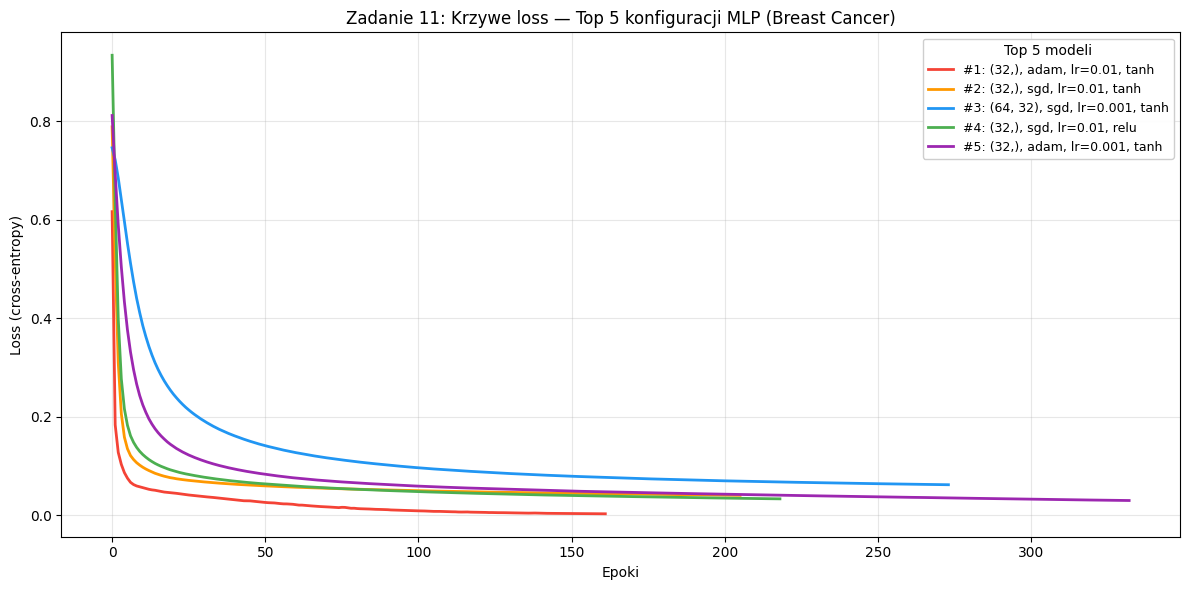

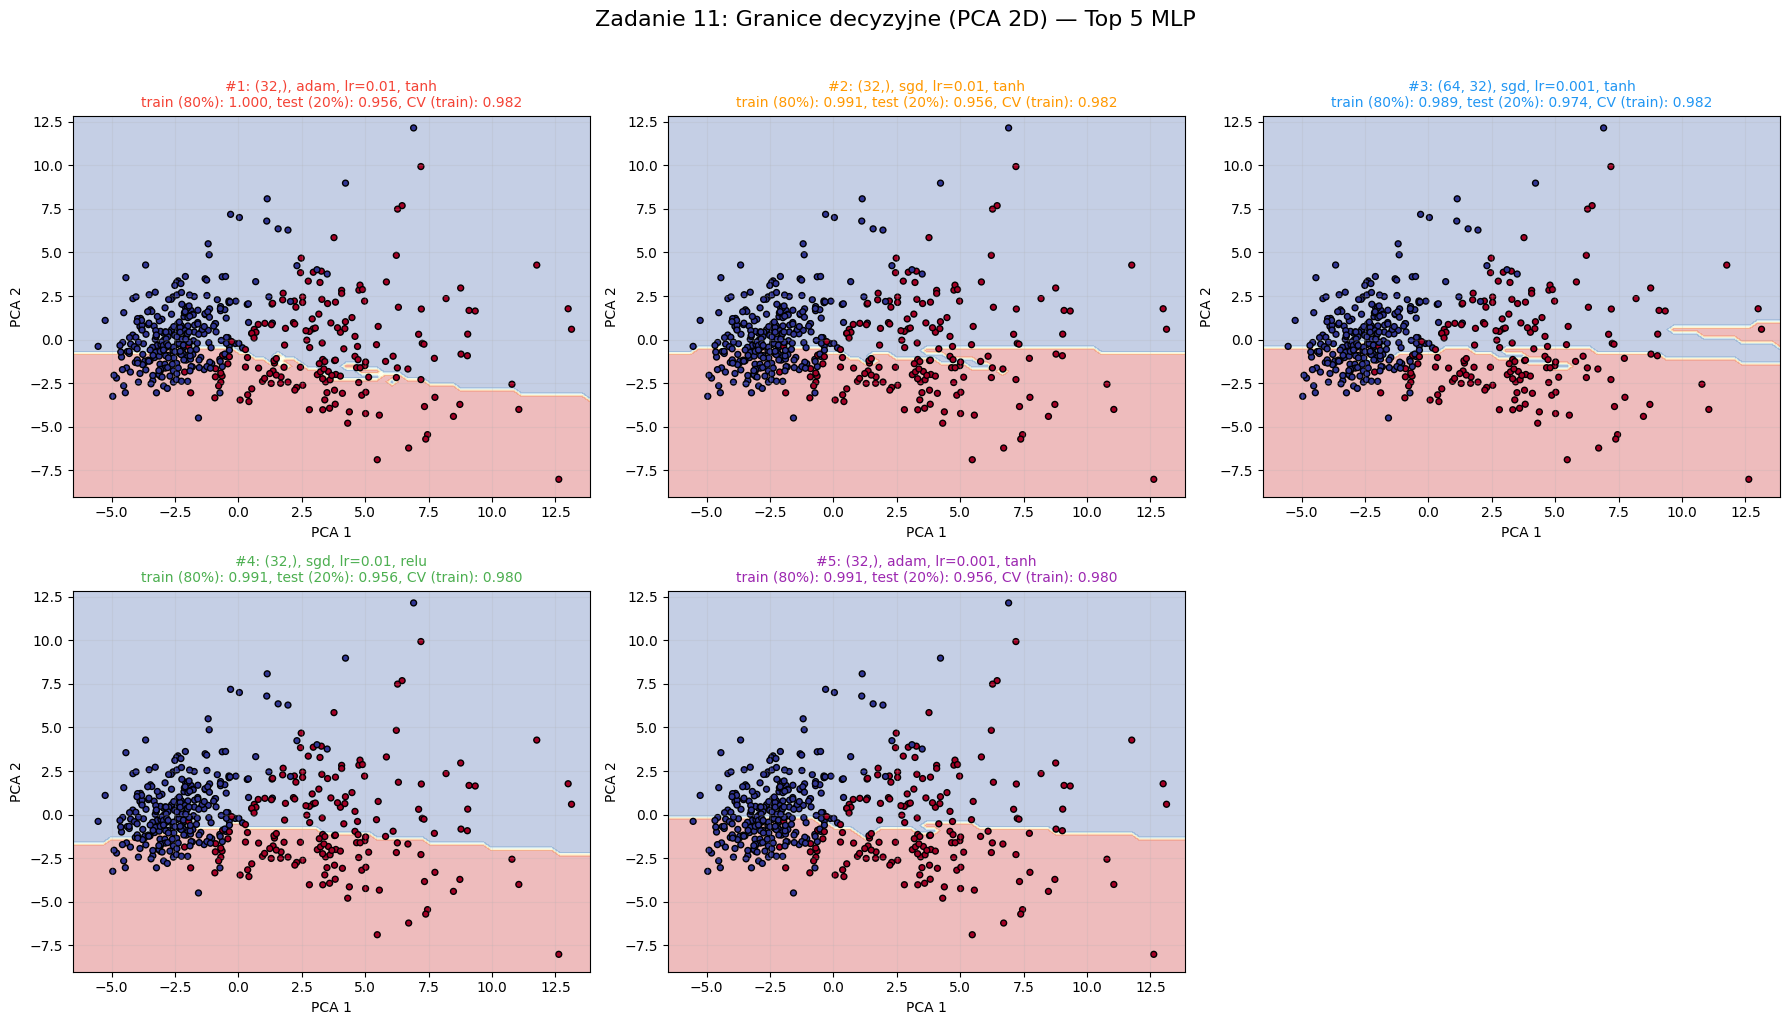


=== PODSUMOWANIE — TOP 5 KONFIGURACJI MLP (GridSearchCV, cv=5) ===
 Miejsce CV accuracy (train, 5-fold)  Test accuracy (20%) Architektura Solver    LR Activation  Końcowy loss  Epoki
       1             0.9824 ± 0.0132             0.956140        (32,)   adam 0.010       tanh      0.003181    162
       2             0.9824 ± 0.0132             0.956140        (32,)    sgd 0.010       tanh      0.040688    206
       3             0.9824 ± 0.0112             0.973684     (64, 32)    sgd 0.001       tanh      0.062215    274
       4             0.9802 ± 0.0162             0.956140        (32,)    sgd 0.010       relu      0.033551    219
       5             0.9802 ± 0.0128             0.956140        (32,)   adam 0.001       tanh      0.030171    333

=== SZCZEGÓŁY PARAMETRÓW (Top 5) ===
1. CV (train): 0.9824 (+/- 0.0132) | Test (20%): 0.9561 | {'activation': 'tanh', 'hidden_layer_sizes': (32,), 'learning_rate_init': 0.01, 'solver': 'adam'}
2. CV (train): 0.9824 (+/- 0.0132) | Test 

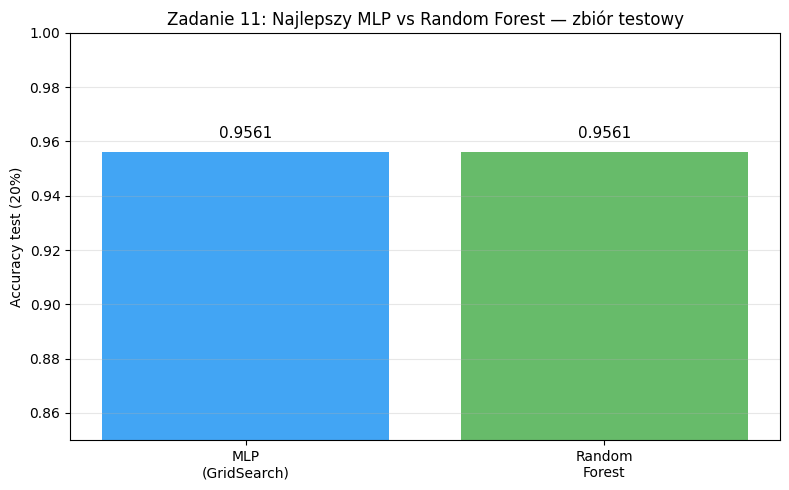


=== SZCZEGÓŁY (train vs test) ===
Train = 80% danych | Test = 20% (niewidziane podczas GridSearch i treningu)

MLP — najlepsze parametry z GridSearch:
  CV accuracy (train, 5-fold): 0.9824
  Accuracy train (cały zbiór): 1.0000
  Accuracy test (20%):           0.9561

Random Forest (n=100):
  Accuracy train (cały zbiór): 1.0000
  Accuracy test (20%):         0.9561

WNIOSKI — TOP 5 MLP vs Random Forest
1. Najlepsza konfiguracja w CV: {'activation': 'tanh', 'hidden_layer_sizes': (32,), 'learning_rate_init': 0.01, 'solver': 'adam'}
   CV (train): 0.9824 ± 0.0132, test (20%): 0.9561
2. Top 5 modeli ma zbliżone wyniki CV (~0.98) — różnią się solverem, aktywacją i architekturą.
3. Krzywe loss: Adam i tanh/reLU pokazują stabilniejszy spadek niż trudniejsze kombinacje (np. SGD).
4. Granice w PCA 2D są przybliżeniem (30 cech → 2D), ale pozwalają porównać separację klas.
5. Na teście (20%): MLP 0.9561 vs RF 0.9561 — remis.


In [7]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

import pandas as pd
import warnings
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")
warnings.showwarning = lambda *args, **kwargs: None
np.seterr(all="ignore")

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import cross_validate


def fit_quiet(model, X, y):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return model.fit(X, y)


def params_from_row(row):
    return {k.replace("mlp__", ""): v for k, v in row["params"].items()}


def make_mlp_pipeline(**mlp_kwargs):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(max_iter=1000, random_state=42, **mlp_kwargs)),
    ])


# 1. Przygotowanie danych
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42, stratify=data.target
)

# 2. Pipeline + siatka hiperparametrów
pipeline = make_mlp_pipeline()
param_grid = {
    "mlp__hidden_layer_sizes": [(32,), (64, 32), (128, 64)],
    "mlp__solver": ["adam", "sgd"],
    "mlp__learning_rate_init": [0.001, 0.01],
    "mlp__activation": ["relu", "tanh"],
}

# 3. GridSearchCV
print("Rozpoczynam przeszukiwanie siatki (GridSearchCV). To może potrwać kilkanaście sekund...")
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=1,
)
grid_search.fit(X_train, y_train)

results_df = pd.DataFrame(grid_search.cv_results_)
top_5 = results_df.nsmallest(5, "rank_test_score").copy()

# 4. Ponowny trening Top 5 (krzywe loss + accuracy na teście)
top5_fitted = []
summary_rows = []

for rank, (_, row) in enumerate(top_5.iterrows(), 1):
    clean = params_from_row(row)
    model = make_mlp_pipeline(**clean)
    fit_quiet(model, X_train, y_train)
    mlp = model.named_steps["mlp"]
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    train_f1 = f1_score(y_train, y_pred_train)
    test_f1 = f1_score(y_test, y_pred_test)

    top5_fitted.append((rank, clean, model, mlp, row, test_acc, test_f1, train_acc, train_f1))
    summary_rows.append({
        "Miejsce": rank,
        "CV accuracy (train, 5-fold)": f"{row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}",
        "Test accuracy (20%)": test_acc,
        "Test F1 (20%)": test_f1,
        "Architektura": str(clean["hidden_layer_sizes"]),
        "Solver": clean["solver"],
        "LR": clean["learning_rate_init"],
        "Activation": clean["activation"],
        "Końcowy loss": mlp.loss_curve_[-1],
        "Epoki": mlp.n_iter_,
    })

summary_df = pd.DataFrame(summary_rows)

# 5. Wykresy: 1× loss (5 krzywych) + siatka 2×3 granic decyzyjnych (PCA 2D)
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_train)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

h = 0.3
x_min, x_max = X_pca[:, 0].min() - 1.0, X_pca[:, 0].max() + 1.0
y_min, y_max = X_pca[:, 1].min() - 1.0, X_pca[:, 1].max() + 1.0
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h),
)
grid_pca = np.c_[xx.ravel(), yy.ravel()]
grid_orig = pca.inverse_transform(grid_pca)

colors = ["#F44336", "#FF9800", "#2196F3", "#4CAF50", "#9C27B0"]

def model_label(rank, clean):
    return (
        f"#{rank}: {clean['hidden_layer_sizes']}, {clean['solver']}, "
        f"lr={clean['learning_rate_init']}, {clean['activation']}"
    )

# --- Wykres 1: wszystkie 5 krzywych loss na jednym panelu ---
fig_loss, ax_loss = plt.subplots(figsize=(12, 6))
for i, (rank, clean, model, mlp, row, test_acc, test_f1, train_acc, train_f1) in enumerate(top5_fitted):
    ax_loss.plot(
        mlp.loss_curve_,
        color=colors[i],
        linewidth=2,
        label=model_label(rank, clean),
    )
ax_loss.set_xlabel("Epoki")
ax_loss.set_ylabel("Loss (cross-entropy)")
ax_loss.set_title("Zadanie 11: Krzywe loss — Top 5 konfiguracji MLP (Breast Cancer)")
ax_loss.grid(True, alpha=0.3)
ax_loss.legend(loc="upper right", fontsize=9, framealpha=0.95, title="Top 5 modeli")
plt.tight_layout()
plt.show()

# --- Wykres 2: 5 osobnych granic decyzyjnych (PCA 2D) ---
fig_bd, axes_bd = plt.subplots(2, 3, figsize=(18, 10))
for i, (rank, clean, model, mlp, row, test_acc, test_f1, train_acc, train_f1) in enumerate(top5_fitted):
    r, c = divmod(i, 3)
    ax = axes_bd[r, c]

    Z = model.predict(grid_orig).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
    ax.scatter(
        X_pca[:, 0], X_pca[:, 1], c=y_train, cmap="RdYlBu", edgecolors="k", s=18
    )
    ax.set_title(
        f"{model_label(rank, clean)}\n"
        f"train: acc {train_acc:.3f}, F1 {train_f1:.3f} | test: acc {test_acc:.3f}, F1 {test_f1:.3f} | CV: {row['mean_test_score']:.3f}",
        fontsize=10,
        color=colors[i],
    )
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    ax.grid(True, alpha=0.2)

axes_bd[1, 2].axis("off")
fig_bd.suptitle(
    "Zadanie 11: Granice decyzyjne (PCA 2D) — Top 5 MLP",
    fontsize=16,
    y=1.02,
)
plt.tight_layout()
plt.show()

# 6. Tabela podsumowania Top 5
print("\n=== PODSUMOWANIE — TOP 5 KONFIGURACJI MLP (GridSearchCV, cv=5) ===")
print(summary_df.to_string(index=False))

print("\n=== SZCZEGÓŁY PARAMETRÓW (Top 5) ===")
for rank, clean, _, _, row, test_acc, test_f1, train_acc, train_f1 in top5_fitted:
    print(
        f"{rank}. CV (train): {row['mean_test_score']:.4f} (+/- {row['std_test_score']:.4f}) | "
        f"Test (20%): acc {test_acc:.4f}, F1 {test_f1:.4f} | {clean}"
    )

# 7. Porównanie najlepszego MLP z Random Forest
best_mlp = grid_search.best_estimator_
mlp_pred_train = best_mlp.predict(X_train)
mlp_pred_test = best_mlp.predict(X_test)
mlp_test_acc = accuracy_score(y_test, mlp_pred_test)
mlp_train_acc = accuracy_score(y_train, mlp_pred_train)
mlp_test_f1 = f1_score(y_test, mlp_pred_test)
mlp_train_f1 = f1_score(y_train, mlp_pred_train)
best_params = params_from_row(top_5.iloc[0])

mlp_cv = cross_validate(
    best_mlp, X_train, y_train, cv=5,
    scoring={"accuracy": "accuracy", "f1": "f1"},
    n_jobs=1,
)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)
fit_quiet(rf, X_train, y_train)
rf_pred_train = rf.predict(X_train)
rf_pred_test = rf.predict(X_test)
rf_test_acc = accuracy_score(y_test, rf_pred_test)
rf_train_acc = accuracy_score(y_train, rf_pred_train)
rf_test_f1 = f1_score(y_test, rf_pred_test)
rf_train_f1 = f1_score(y_train, rf_pred_train)

rf_cv = cross_validate(
    rf, X_train, y_train, cv=5,
    scoring={"accuracy": "accuracy", "f1": "f1"},
    n_jobs=1,
)

comparison_df = pd.DataFrame({
    "Model": [
        "MLP (GridSearch — najlepsze parametry)",
        "Random Forest (n_estimators=100)",
    ],
    "CV accuracy (train, 5-fold)": [
        f"{grid_search.best_score_:.4f}",
        f"{rf_cv['test_accuracy'].mean():.4f} ± {rf_cv['test_accuracy'].std():.4f}",
    ],
    "CV F1 (train, 5-fold)": [
        f"{mlp_cv['test_f1'].mean():.4f} ± {mlp_cv['test_f1'].std():.4f}",
        f"{rf_cv['test_f1'].mean():.4f} ± {rf_cv['test_f1'].std():.4f}",
    ],
    "Accuracy train (80%)": [mlp_train_acc, rf_train_acc],
    "Accuracy test (20%)": [mlp_test_acc, rf_test_acc],
    "F1 train (80%)": [mlp_train_f1, rf_train_f1],
    "F1 test (20%)": [mlp_test_f1, rf_test_f1],
})

print("\n=== PORÓWNANIE: NAJLEPSZY MLP vs RANDOM FOREST ===")
print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))
print(f"\nParametry najlepszego MLP: {best_params}")

winner_acc = "remis"
if mlp_test_acc > rf_test_acc:
    winner_acc = "MLP"
elif rf_test_acc > mlp_test_acc:
    winner_acc = "Random Forest"

winner_f1 = "remis"
if mlp_test_f1 > rf_test_f1:
    winner_f1 = "MLP"
elif rf_test_f1 > mlp_test_f1:
    winner_f1 = "Random Forest"

print(f"Zwycięzca na teście (20%) — accuracy: {winner_acc} "
      f"(MLP {mlp_test_acc:.4f} vs RF {rf_test_acc:.4f})")
print(f"Zwycięzca na teście (20%) — F1: {winner_f1} "
      f"(MLP {mlp_test_f1:.4f} vs RF {rf_test_f1:.4f})")

fig_cmp, ax_cmp = plt.subplots(figsize=(9, 5))
models = ["MLP\n(GridSearch)", "Random\nForest"]
x = np.arange(len(models))
width = 0.35
test_acc_scores = [mlp_test_acc, rf_test_acc]
test_f1_scores = [mlp_test_f1, rf_test_f1]
bars_acc = ax_cmp.bar(x - width / 2, test_acc_scores, width, label="Accuracy", color="#2196F3", alpha=0.85)
bars_f1 = ax_cmp.bar(x + width / 2, test_f1_scores, width, label="F1", color="#FF9800", alpha=0.85)
ax_cmp.set_xticks(x)
ax_cmp.set_xticklabels(models)
ax_cmp.set_ylim(0.85, 1.0)
ax_cmp.set_ylabel("Wynik na teście (20%)")
ax_cmp.set_title("Zadanie 11: Najlepszy MLP vs Random Forest — accuracy i F1")
ax_cmp.legend()
ax_cmp.grid(True, axis="y", alpha=0.3)
for bar, score in zip(bars_acc, test_acc_scores):
    ax_cmp.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{score:.4f}", ha="center", fontsize=10)
for bar, score in zip(bars_f1, test_f1_scores):
    ax_cmp.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{score:.4f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

target_names = ["malignant", "benign"]
print("\n=== classification_report — MLP (test, 20%) ===")
print(classification_report(y_test, mlp_pred_test, target_names=target_names))
print("=== classification_report — Random Forest (test, 20%) ===")
print(classification_report(y_test, rf_pred_test, target_names=target_names))

print("\n=== SZCZEGÓŁY (train vs test) ===")
print("Train = 80% danych | Test = 20% (niewidziane podczas GridSearch i treningu)\n")
print("MLP — najlepsze parametry z GridSearch:")
print(f"  CV accuracy (train, 5-fold): {grid_search.best_score_:.4f}")
print(f"  CV F1 (train, 5-fold):         {mlp_cv['test_f1'].mean():.4f} (+/- {mlp_cv['test_f1'].std():.4f})")
print(f"  Accuracy train (80%):          {mlp_train_acc:.4f}")
print(f"  Accuracy test (20%):           {mlp_test_acc:.4f}")
print(f"  F1 train (80%):                {mlp_train_f1:.4f}")
print(f"  F1 test (20%):                 {mlp_test_f1:.4f}")
print("\nRandom Forest (n=100):")
print(f"  CV accuracy (train, 5-fold): {rf_cv['test_accuracy'].mean():.4f} (+/- {rf_cv['test_accuracy'].std():.4f})")
print(f"  CV F1 (train, 5-fold):       {rf_cv['test_f1'].mean():.4f} (+/- {rf_cv['test_f1'].std():.4f})")
print(f"  Accuracy train (80%):        {rf_train_acc:.4f}")
print(f"  Accuracy test (20%):         {rf_test_acc:.4f}")
print(f"  F1 train (80%):              {rf_train_f1:.4f}")
print(f"  F1 test (20%):               {rf_test_f1:.4f}")

print("\n" + "=" * 60)
print("WNIOSKI — TOP 5 MLP vs Random Forest")
print("=" * 60)
best_row = summary_df.iloc[0]
print(f"1. Najlepsza konfiguracja w CV: {best_params}")
print(f"   CV (train): {best_row['CV accuracy (train, 5-fold)']}, "
      f"test (20%): acc {best_row['Test accuracy (20%)']:.4f}, F1 {best_row['Test F1 (20%)']:.4f}")
print("2. Top 5 modeli ma zbliżone wyniki CV (~0.98) — różnią się solverem, aktywacją i architekturą.")
print("3. Krzywe loss: Adam i tanh/reLU pokazują stabilniejszy spadek niż trudniejsze kombinacje (np. SGD).")
print("4. Granice w PCA 2D są przybliżeniem (30 cech → 2D), ale pozwalają porównać separację klas.")
print(f"5. Na teście (20%): accuracy MLP {mlp_test_acc:.4f} vs RF {rf_test_acc:.4f}, "
      f"F1 MLP {mlp_test_f1:.4f} vs RF {rf_test_f1:.4f}.")
print(f"   Accuracy: {'remis' if abs(mlp_test_acc - rf_test_acc) < 1e-6 else ('MLP lepszy' if mlp_test_acc > rf_test_acc else 'RF lepszy')}; "
      f"F1: {'remis' if abs(mlp_test_f1 - rf_test_f1) < 1e-6 else ('MLP lepszy' if mlp_test_f1 > rf_test_f1 else 'RF lepszy')}.")
print("=" * 60)
